# 🥗 Diet Optimization Using Linear & Nonlinear Programming
### ARTI-309 & MATH-403 — Final Project
**Topic:** Minimizing Daily Diet Cost While Meeting Nutritional Requirements

---


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import linprog, minimize
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

COLORS = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#44BBA4',
          '#E94F37','#393E41','#F5A623','#7B2D8B','#3B1F2B']

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


## 2. Load & Explore the Dataset

In [2]:
# Load the USDA food composition dataset
df_raw = pd.read_csv('food.csv')

print(f"Dataset shape: {df_raw.shape}")
print(f"Total food categories: {df_raw['Category'].nunique()}")
print(f"\nColumn names:")
for col in df_raw.columns:
    print(f"   {col}")


Dataset shape: (7083, 38)
Total food categories: 2429

Column names:
   Category
   Description
   Nutrient Data Bank Number
   Data.Alpha Carotene
   Data.Beta Carotene
   Data.Beta Cryptoxanthin
   Data.Carbohydrate
   Data.Cholesterol
   Data.Choline
   Data.Fiber
   Data.Lutein and Zeaxanthin
   Data.Lycopene
   Data.Niacin
   Data.Protein
   Data.Retinol
   Data.Riboflavin
   Data.Selenium
   Data.Sugar Total
   Data.Thiamin
   Data.Water
   Data.Fat.Monosaturated Fat
   Data.Fat.Polysaturated Fat
   Data.Fat.Saturated Fat
   Data.Fat.Total Lipid
   Data.Major Minerals.Calcium
   Data.Major Minerals.Copper
   Data.Major Minerals.Iron
   Data.Major Minerals.Magnesium
   Data.Major Minerals.Phosphorus
   Data.Major Minerals.Potassium
   Data.Major Minerals.Sodium
   Data.Major Minerals.Zinc
   Data.Vitamins.Vitamin A - RAE
   Data.Vitamins.Vitamin B12
   Data.Vitamins.Vitamin B6
   Data.Vitamins.Vitamin C
   Data.Vitamins.Vitamin E
   Data.Vitamins.Vitamin K


In [3]:
# Preview the first few rows
df_raw.head()


,Category,Description,Nutrient Data Bank Number,Data.Alpha Carotene,Data.Beta Carotene,Data.Beta Cryptoxanthin,Data.Carbohydrate,Data.Cholesterol,Data.Choline,Data.Fiber,...,Data.Major Minerals.Phosphorus,Data.Major Minerals.Potassium,Data.Major Minerals.Sodium,Data.Major Minerals.Zinc,Data.Vitamins.Vitamin A - RAE,Data.Vitamins.Vitamin B12,Data.Vitamins.Vitamin B6,Data.Vitamins.Vitamin C,Data.Vitamins.Vitamin E,Data.Vitamins.Vitamin K
0,Milk,"Milk, human",11000000,0,7,0,6.89,14,16.0,0.0,...,14,51,17,0.17,61,0.05,0.011,5.0,0.08,0.3
1,Milk,"Milk, NFS",11100000,0,4,0,4.87,8,17.9,0.0,...,103,157,39,0.42,59,0.56,0.060,0.1,0.03,0.2
2,Milk,"Milk, whole",11111000,0,7,0,4.67,12,17.8,0.0,...,101,150,38,0.41,32,0.54,0.061,0.0,0.05,0.3
3,Milk,"Milk, low sodium, whole",11111100,0,7,0,4.46,14,16.0,0.0,...,86,253,3,0.38,29,0.36,0.034,0.9,0.08,0.3
4,Milk,"Milk, calcium fortified, whole",11111150,0,7,0,4.67,12,17.8,0.0,...,101,150,38,0.41,32,0.54,0.061,0.0,0.05,0.3


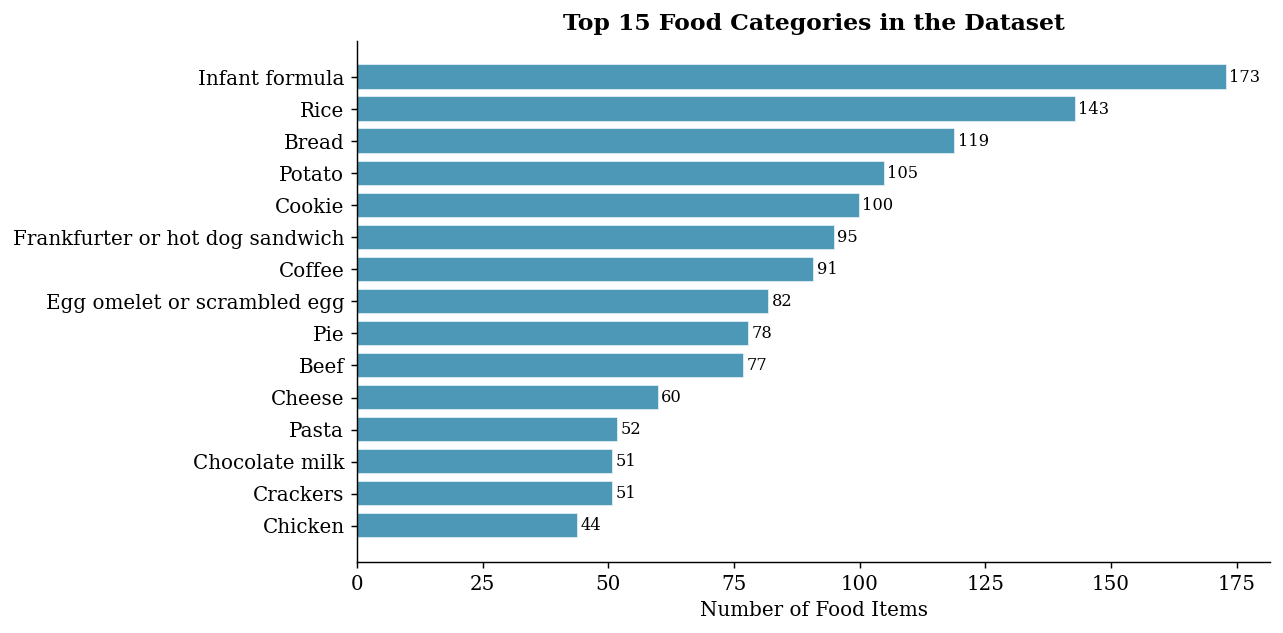

Figure saved.


In [4]:
# Check distribution of food categories (top 15)
top_categories = df_raw['Category'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_categories.index[::-1], top_categories.values[::-1],
               color=COLORS[0], alpha=0.85, edgecolor='white')
ax.set_xlabel('Number of Food Items')
ax.set_title('Top 15 Food Categories in the Dataset')
for bar, val in zip(bars, top_categories.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figure0_category_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


## 3. Data Preparation

We select a representative subset of common food categories from the dataset 
and pick one food per category (the first entry) to keep the optimization 
problem manageable and interpretable.

We also assign an **estimated cost per 100g serving** based on average US 
market prices (since the dataset does not include price data).


In [5]:
# Select representative food categories
selected_categories = [
    'Chicken',        'Egg',           'Milk',          'Rice',
    'Broccoli',       'Spinach',       'Banana',        'Apple',
    'Oat',            'Tuna',          'Lentil',        'Bread',
    'Peanut butter',  'Orange',        'Sweet potato',  'Yogurt',
    'Almond',         'Carrot',        'Salmon',        'Beef'
]

# Filter dataset: pick the first match for each category keyword
selected_rows = []
for cat in selected_categories:
    match = df_raw[df_raw['Category'].str.contains(cat, case=False, na=False)]
    if not match.empty:
        selected_rows.append(match.iloc[0])

df = pd.DataFrame(selected_rows).reset_index(drop=True)

# Estimated cost per 100g serving (USD) — based on average US grocery prices
cost_map = {
    0: 1.20,  # Chicken
    1: 0.25,  # Egg
    2: 0.10,  # Milk
    3: 0.15,  # Rice
    4: 0.50,  # Broccoli
    5: 0.45,  # Spinach
    6: 0.20,  # Banana
    7: 0.35,  # Apple
    8: 0.12,  # Oat
    9: 0.75,  # Tuna
    10: 0.25, # Lentil
    11: 0.20, # Bread
    12: 0.35, # Peanut butter
    13: 0.30, # Orange
    14: 0.25, # Sweet potato
    15: 0.50, # Yogurt
    16: 0.60, # Almond
    17: 0.18, # Carrot
    18: 1.50, # Salmon
    19: 1.30, # Beef
}
df['Cost_per_100g'] = [cost_map[i] for i in range(len(df))]

# Select the nutrients we will use as constraints
nutrient_cols = {
    'Data.Protein'               : 'Protein (g)',
    'Data.Fat.Total Lipid'       : 'Fat (g)',
    'Data.Carbohydrate'          : 'Carbs (g)',
    'Data.Fiber'                 : 'Fiber (g)',
    'Data.Major Minerals.Calcium': 'Calcium (mg)',
    'Data.Major Minerals.Iron'   : 'Iron (mg)',
    'Data.Vitamins.Vitamin C'    : 'Vitamin C (mg)',
    'Data.Major Minerals.Potassium': 'Potassium (mg)',
}

df_nutrients = df[['Category','Description','Cost_per_100g'] + list(nutrient_cols.keys())].copy()
df_nutrients.rename(columns=nutrient_cols, inplace=True)
df_nutrients['Food'] = df_nutrients['Description'].str.split(',').str[0]

print(f"Selected {len(df_nutrients)} food items for optimization.")
df_nutrients[['Food','Cost_per_100g'] + list(nutrient_cols.values())]


Selected 20 food items for optimization.


,Food,Cost_per_100g,Protein (g),Fat (g),Carbs (g),Fiber (g),Calcium (mg),Iron (mg),Vitamin C (mg),Potassium (mg)
0,Mock chicken legs,1.20,20.75,13.79,5.27,0.2,22,1.13,0.1,286
1,Eggnog,0.25,4.55,4.19,8.05,0.0,130,0.20,1.5,165
2,Milk,0.10,1.03,4.38,6.89,0.0,32,0.03,5.0,51
3,Rice milk,0.15,0.28,0.97,9.17,0.3,118,0.20,0.0,27
4,Beef and broccoli,0.50,10.55,10.65,5.31,1.4,34,1.25,39.2,307
5,Spinach dip,0.45,7.02,12.94,3.60,0.3,103,0.21,0.7,136
6,Banana split,0.20,2.53,6.90,32.53,1.3,74,0.24,3.6,220
7,Scrapple,0.35,8.57,14.76,14.96,0.3,6,1.31,1.3,143
8,Goat's milk,0.12,3.56,4.14,4.45,0.0,134,0.05,1.3,204
9,Tuna,0.75,24.40,0.49,0.00,0.0,4,0.77,0.0,441


In [6]:
# Summary statistics of selected foods
df_nutrients[list(nutrient_cols.values())].describe().round(2)


,Protein (g),Fat (g),Carbs (g),Fiber (g),Calcium (mg),Iron (mg),Vitamin C (mg),Potassium (mg)
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,10.60,8.23,9.28,0.93,57.70,0.88,6.61,245.25
std,9.39,11.12,8.80,1.85,60.47,0.86,13.40,142.15
min,0.28,0.10,0.00,0.00,4.00,0.03,0.00,27.00
25%,3.30,2.70,4.24,0.00,14.00,0.21,0.00,141.50
50%,7.70,4.39,6.96,0.25,27.00,0.57,1.10,214.50
75%,20.56,11.16,12.29,0.90,106.75,1.27,3.38,348.75
max,29.23,51.10,32.53,7.30,183.00,3.11,39.20,564.00


## 4. Exploratory Data Analysis (EDA)
Before optimizing, we explore the nutritional profiles of our selected foods 
to understand the data and identify patterns.


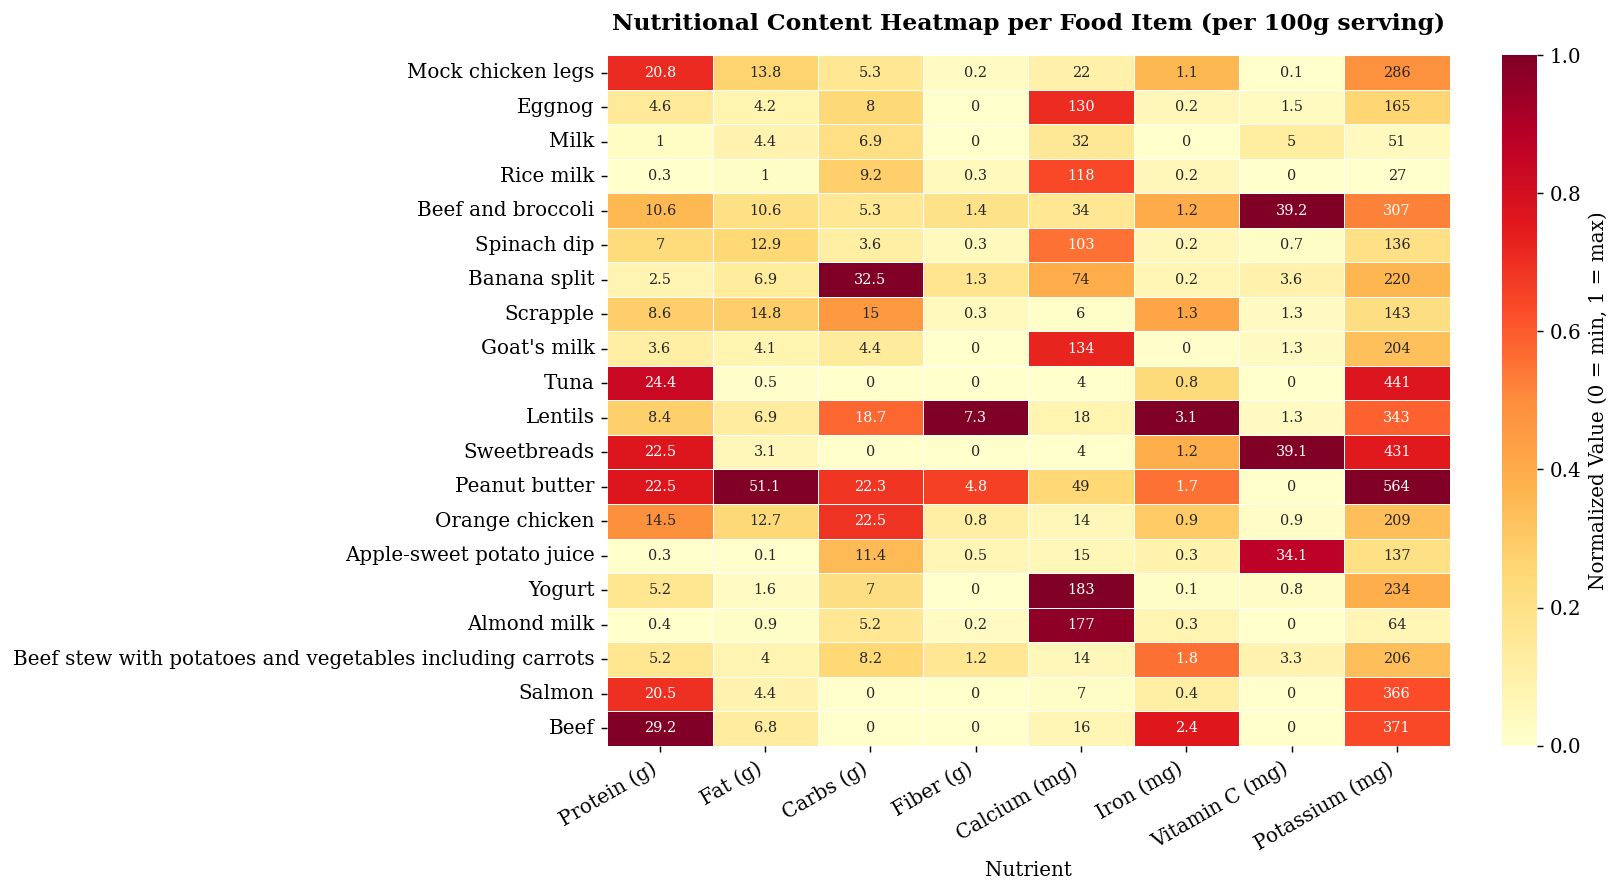

In [7]:
# ── Heatmap: Nutritional content across all selected foods ──
fig, ax = plt.subplots(figsize=(13, 7))

nutrient_matrix = df_nutrients[list(nutrient_cols.values())].astype(float)
nutrient_norm   = (nutrient_matrix - nutrient_matrix.min()) /                   (nutrient_matrix.max() - nutrient_matrix.min() + 1e-9)

sns.heatmap(
    nutrient_norm.set_index(df_nutrients['Food']),
    annot=nutrient_matrix.round(1).values,
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Normalized Value (0 = min, 1 = max)'},
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Nutritional Content Heatmap per Food Item (per 100g serving)', pad=14)
ax.set_xlabel('Nutrient')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figure1_nutrition_heatmap.png', bbox_inches='tight')
plt.show()


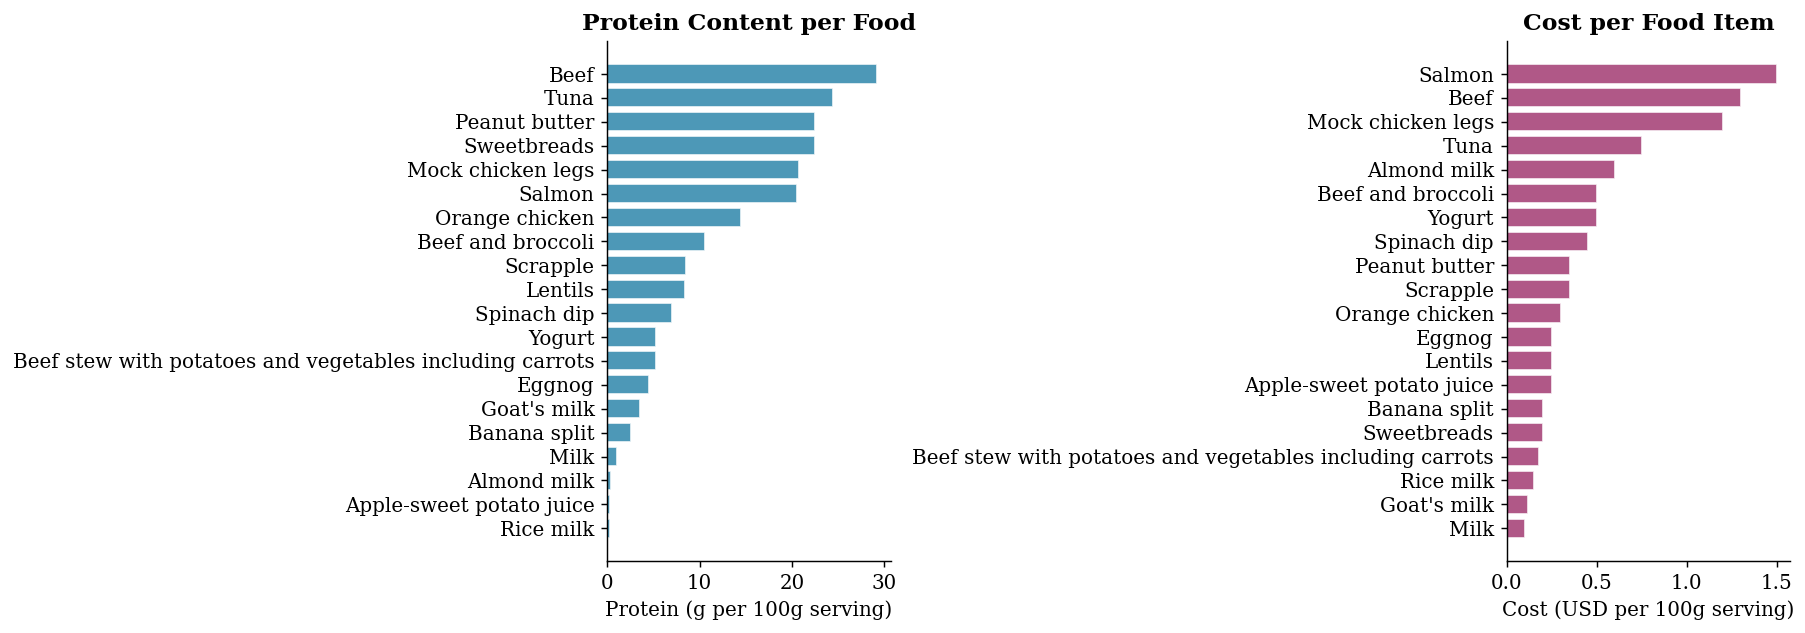

In [8]:
# ── Bar chart: Protein content per food ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Protein
order_prot = df_nutrients.sort_values('Protein (g)', ascending=True)
axes[0].barh(order_prot['Food'], order_prot['Protein (g)'],
             color=COLORS[0], alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Protein (g per 100g serving)')
axes[0].set_title('Protein Content per Food')

# Cost
order_cost = df_nutrients.sort_values('Cost_per_100g', ascending=True)
axes[1].barh(order_cost['Food'], order_cost['Cost_per_100g'],
             color=COLORS[1], alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Cost (USD per 100g serving)')
axes[1].set_title('Cost per Food Item')

plt.tight_layout()
plt.savefig('figure2_protein_cost.png', bbox_inches='tight')
plt.show()


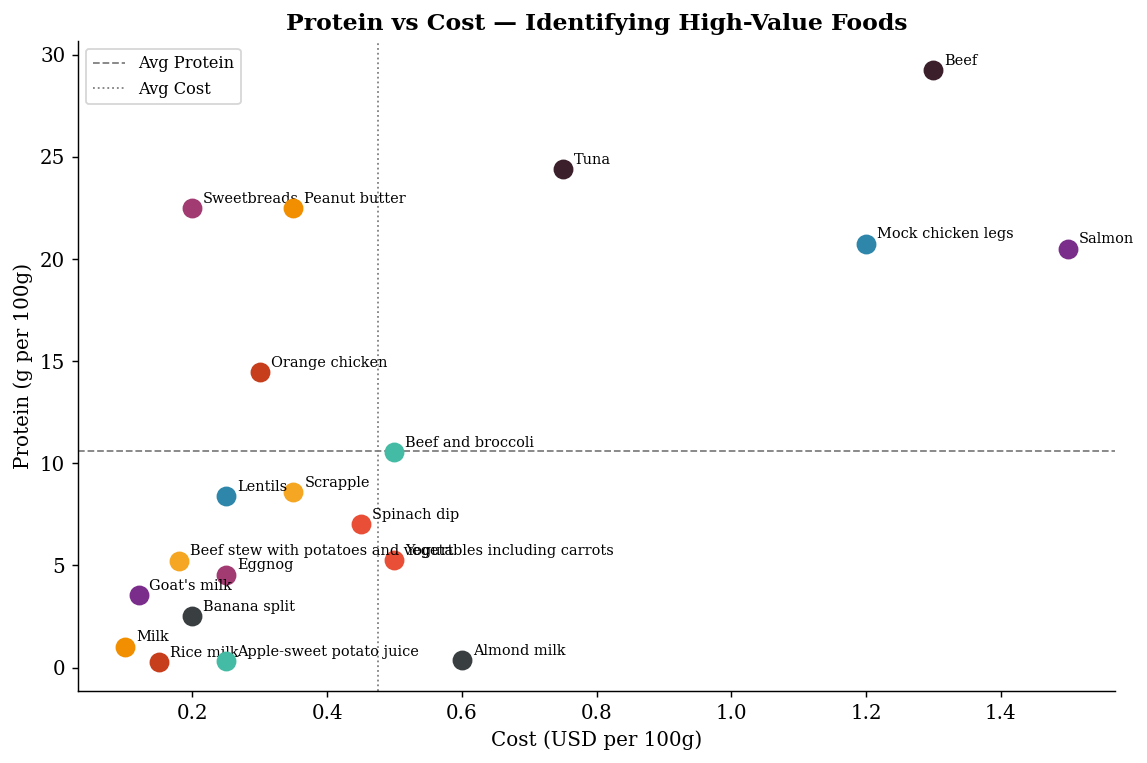

Foods in top-left quadrant (high protein, low cost) are the best LP candidates.


In [9]:
# ── Scatter: Protein vs Cost (value-for-money view) ──
fig, ax = plt.subplots(figsize=(9, 6))

for i, row in df_nutrients.iterrows():
    ax.scatter(row['Cost_per_100g'], row['Protein (g)'],
               color=COLORS[i % len(COLORS)], s=100, zorder=3)
    ax.annotate(row['Food'], (row['Cost_per_100g'], row['Protein (g)']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Cost (USD per 100g)')
ax.set_ylabel('Protein (g per 100g)')
ax.set_title('Protein vs Cost — Identifying High-Value Foods')
ax.axhline(df_nutrients['Protein (g)'].mean(), color='gray',
           linestyle='--', linewidth=1, label='Avg Protein')
ax.axvline(df_nutrients['Cost_per_100g'].mean(), color='gray',
           linestyle=':', linewidth=1, label='Avg Cost')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figure3_protein_vs_cost.png', bbox_inches='tight')
plt.show()
print("Foods in top-left quadrant (high protein, low cost) are the best LP candidates.")


## 5. Problem Formulation

### Decision Variables
Let $x_i$ = number of 100g servings of food $i$ consumed per day, where $i = 1, 2, ..., n$.

### Objective Function
**Minimize** total daily food cost:
$$\text{Minimize } Z = \sum_{i=1}^{n} c_i \cdot x_i$$

where $c_i$ is the cost per 100g serving of food $i$.

### Constraints (Daily Nutritional Requirements)
$$\sum_{i=1}^{n} a_{ij} \cdot x_i \geq b_j \quad \forall j$$

| Nutrient | Min. Daily Requirement |
|---|---|
| Protein | 50 g |
| Fat | 44 g |
| Carbohydrates | 225 g |
| Fiber | 25 g |
| Calcium | 1000 mg |
| Iron | 8 mg |
| Vitamin C | 60 mg |
| Potassium | 3500 mg |

### Non-negativity
$$x_i \geq 0 \quad \forall i$$

### Upper Bound
$$x_i \leq 10 \quad \forall i \quad \text{(max 10 servings × 100g = 1kg per food)}$$


In [10]:
# ── Define LP inputs ──────────────────────────────────────

nutrients_used = list(nutrient_cols.values())

# Cost vector (objective)
c = df_nutrients['Cost_per_100g'].values.astype(float)

# Nutrient matrix: shape (n_foods, n_nutrients)
A = df_nutrients[nutrients_used].values.astype(float)

# Daily minimum requirements (same order as nutrients_used)
b = np.array([
    50,    # Protein (g)
    44,    # Fat (g)
    225,   # Carbs (g)
    25,    # Fiber (g)
    1000,  # Calcium (mg)
    8,     # Iron (mg)
    60,    # Vitamin C (mg)
    3500,  # Potassium (mg)
])

req_units = ['g', 'g', 'g', 'g', 'mg', 'mg', 'mg', 'mg']

n_foods    = len(df_nutrients)
n_nutrients = len(nutrients_used)

# Bounds: 0 to 10 servings per food
bounds = [(0, 10)] * n_foods

print(f"Number of food items (decision variables): {n_foods}")
print(f"Number of nutritional constraints        : {n_nutrients}")
print(f"\nNutrient matrix A shape: {A.shape}  (foods × nutrients)")
print(f"Cost vector c shape    : {c.shape}")
print(f"Requirements vector b  : {b}")


Number of food items (decision variables): 20
Number of nutritional constraints        : 8

Nutrient matrix A shape: (20, 8)  (foods × nutrients)
Cost vector c shape    : (20,)
Requirements vector b  : [  50   44  225   25 1000    8   60 3500]


## 6. Linear Programming (LP)

We use `scipy.optimize.linprog` with the **HiGHS** solver, which implements 
the Simplex and Interior Point methods for LP problems.

The standard form for `linprog` is:
$$\text{Minimize } c^T x \text{ subject to } A_{ub} x \leq b_{ub}$$

Since our constraints are **minimums** ($Ax \geq b$), we multiply both 
sides by $-1$ to convert them: $-Ax \leq -b$.


In [11]:
from scipy.optimize import linprog

# linprog requires: A_ub @ x <= b_ub
# Our constraints: A.T @ x >= b  →  -A.T @ x <= -b
lp_result = linprog(
    c      = c,
    A_ub   = -A.T,    # shape: (n_nutrients, n_foods)
    b_ub   = -b,
    bounds = bounds,
    method = 'highs'
)

print("=" * 55)
print("LINEAR PROGRAMMING RESULTS")
print("=" * 55)
print(f"Status  : {lp_result.message}")
print(f"\n💰 Optimal Daily Cost: ${lp_result.fun:.2f}")

lp_x = lp_result.x
lp_cost = lp_result.fun
lp_nutrients_achieved = A.T @ lp_x

print(f"\n{'Food':<25} {'Servings':>10} {'Cost ($)':>10}")
print("-" * 47)
for food, qty, cost_i in zip(df_nutrients['Food'], lp_x, c):
    if qty > 0.001:
        print(f"{food:<25} {qty:>10.3f} {qty*cost_i:>10.3f}")
print("-" * 47)
print(f"{'TOTAL':>36} ${lp_cost:>8.2f}")

print(f"\n{'Nutrient':<20} {'Achieved':>10} {'Required':>10} {'Unit':>6} {'%Met':>6}")
print("-" * 56)
for nut, ach, req, unit in zip(nutrients_used, lp_nutrients_achieved, b, req_units):
    pct = ach / req * 100
    flag = '✅' if pct >= 100 else '❌'
    print(f"{flag} {nut:<18} {ach:>10.1f} {req:>10.0f} {unit:>6} {pct:>5.0f}%")


LINEAR PROGRAMMING RESULTS
Status  : Optimization terminated successfully. (HiGHS Status 7: Optimal)

💰 Optimal Daily Cost: $2.44

Food                        Servings   Cost ($)
-----------------------------------------------
Banana split                   4.514      0.903
Goat's milk                    4.316      0.518
Lentils                        1.969      0.492
Sweetbreads                    0.910      0.182
Peanut butter                  0.991      0.347
-----------------------------------------------
                               TOTAL $    2.44

Nutrient               Achieved   Required   Unit   %Met
--------------------------------------------------------
✅ Protein (g)              86.0         50      g   172%
✅ Fat (g)                 116.0         44      g   264%
✅ Carbs (g)               225.0        225      g   100%
✅ Fiber (g)                25.0         25      g   100%
✅ Calcium (mg)           1000.0       1000     mg   100%
✅ Iron (mg)                10.3       

## 7. Nonlinear Programming (NLP)

The LP solution minimizes cost but may produce an extreme diet 
(e.g., eating only a few foods in large quantities). 

We introduce a **nonlinear objective** that penalizes both under- and 
over-consumption of nutrients, promoting a more **balanced** diet:

$$\text{Minimize } Z_{NLP} = \sum_{i=1}^{n} c_i x_i + \lambda \sum_{j=1}^{m} \left(\frac{\sum_i a_{ij} x_i - b_j}{b_j}\right)^2$$

- The first term minimizes cost (same as LP)
- The second term penalizes **normalized** deviation from each nutrient target
- $\lambda$ controls the trade-off between cost and nutritional balance
- We use `scipy.optimize.minimize` with the **SLSQP** (Sequential Least Squares Programming) method


In [12]:
from scipy.optimize import minimize

lambda_ = 0.05   # penalty weight — controls cost vs balance trade-off

def nlp_objective(x):
    cost      = np.dot(c, x)
    achieved  = A.T @ x
    deviation = (achieved - b) / b          # normalized deviation
    penalty   = lambda_ * np.sum(deviation ** 2)
    return cost + penalty

def nlp_gradient(x):
    achieved      = A.T @ x
    deviation     = (achieved - b) / b
    cost_grad     = c
    penalty_grad  = lambda_ * 2 * (A @ (deviation / b))
    return cost_grad + penalty_grad

# Constraints: each nutrient must meet its minimum requirement
nlp_constraints = [
    {'type': 'ineq', 'fun': lambda x, i=i: (A.T @ x)[i] - b[i]}
    for i in range(n_nutrients)
]

# Initial guess: 0.5 servings of each food
x0 = np.ones(n_foods) * 0.5

nlp_result = minimize(
    fun         = nlp_objective,
    x0          = x0,
    jac         = nlp_gradient,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = nlp_constraints,
    options     = {'ftol': 1e-10, 'maxiter': 2000}
)

nlp_x                  = nlp_result.x
nlp_cost               = np.dot(c, nlp_x)
nlp_nutrients_achieved = A.T @ nlp_x

print("=" * 55)
print("NONLINEAR PROGRAMMING RESULTS")
print("=" * 55)
print(f"Status  : {nlp_result.message}")
print(f"\n💰 Optimal Daily Cost: ${nlp_cost:.2f}")

print(f"\n{'Food':<25} {'Servings':>10} {'Cost ($)':>10}")
print("-" * 47)
for food, qty, cost_i in zip(df_nutrients['Food'], nlp_x, c):
    if qty > 0.001:
        print(f"{food:<25} {qty:>10.3f} {qty*cost_i:>10.3f}")
print("-" * 47)
print(f"{'TOTAL':>36} ${nlp_cost:>8.2f}")

print(f"\n{'Nutrient':<20} {'Achieved':>10} {'Required':>10} {'Unit':>6} {'%Met':>6}")
print("-" * 56)
for nut, ach, req, unit in zip(nutrients_used, nlp_nutrients_achieved, b, req_units):
    pct = ach / req * 100
    flag = '✅' if pct >= 100 else '❌'
    print(f"{flag} {nut:<18} {ach:>10.1f} {req:>10.0f} {unit:>6} {pct:>5.0f}%")


NONLINEAR PROGRAMMING RESULTS
Status  : Optimization terminated successfully

💰 Optimal Daily Cost: $2.45

Food                        Servings   Cost ($)
-----------------------------------------------
Banana split                   4.758      0.952
Goat's milk                    4.947      0.594
Lentils                        2.577      0.644
Sweetbreads                    1.300      0.260
-----------------------------------------------
                               TOTAL $    2.45

Nutrient               Achieved   Required   Unit   %Met
--------------------------------------------------------
✅ Protein (g)              80.5         50      g   161%
✅ Fat (g)                  75.0         44      g   170%
✅ Carbs (g)               225.0        225      g   100%
✅ Fiber (g)                25.0         25      g   100%
✅ Calcium (mg)           1066.5       1000     mg   107%
✅ Iron (mg)                11.0          8     mg   138%
✅ Vitamin C (mg)           77.7         60     mg   1

## 8. Results & Comparison

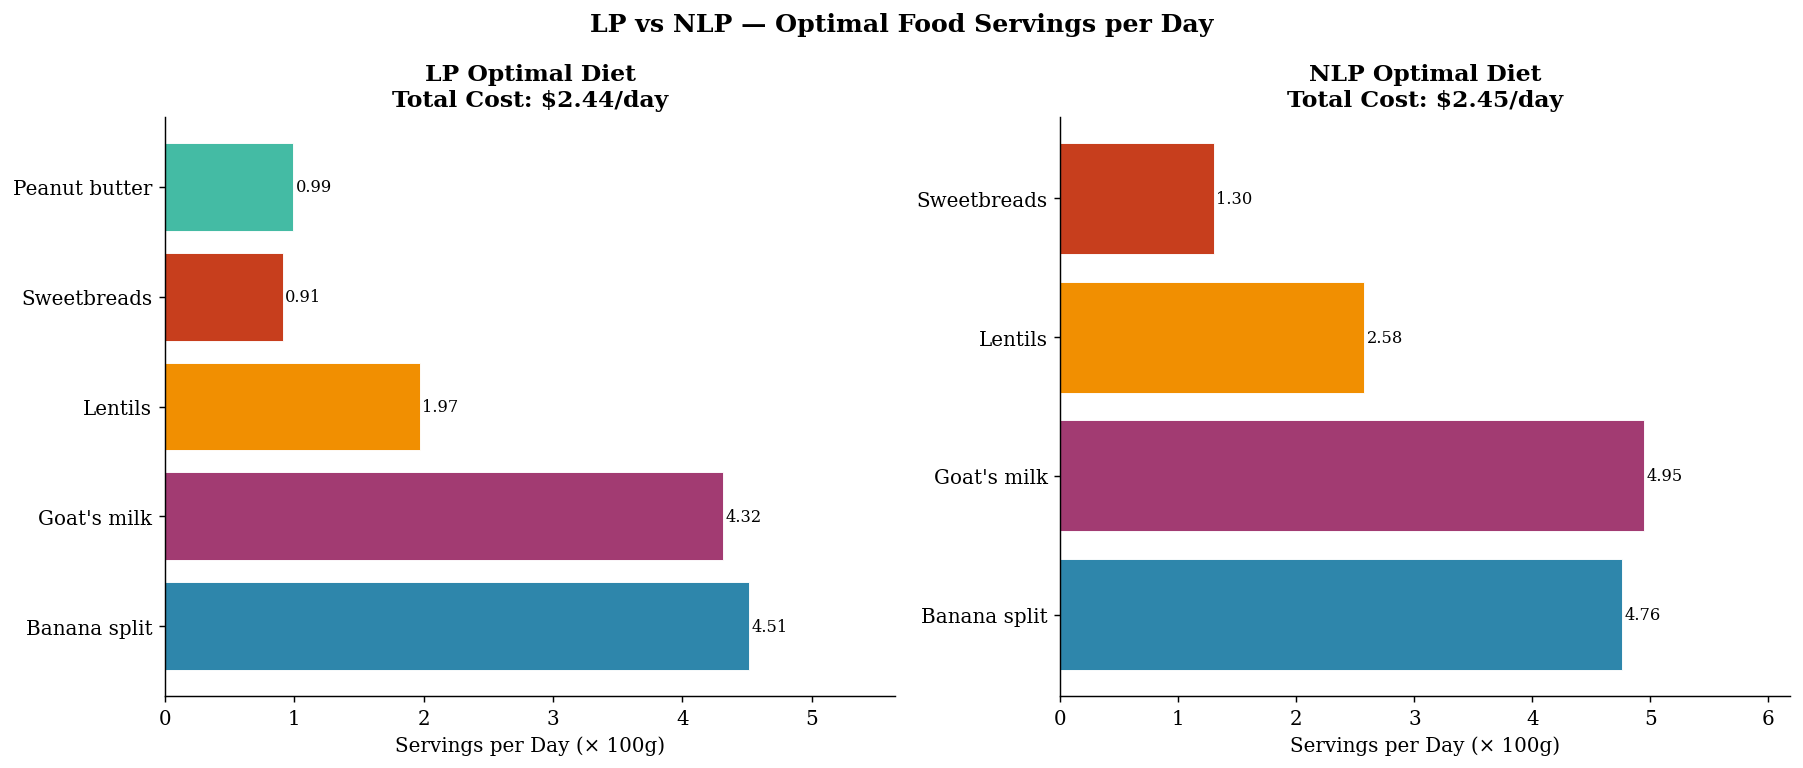

In [13]:
# ── Figure: LP vs NLP Optimal Servings side by side ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_vals, title, cost_val in zip(
    axes,
    [lp_x, nlp_x],
    ['LP Optimal Diet', 'NLP Optimal Diet'],
    [lp_cost, nlp_cost]
):
    mask  = x_vals > 0.001
    foods = df_nutrients['Food'][mask].values
    qty   = x_vals[mask]
    clrs  = [COLORS[i % len(COLORS)] for i in range(len(foods))]
    bars  = ax.barh(foods, qty, color=clrs, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Servings per Day (× 100g)')
    ax.set_title(f'{title}\nTotal Cost: ${cost_val:.2f}/day')
    ax.set_xlim(0, max(qty) * 1.25)
    for bar, val in zip(bars, qty):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('LP vs NLP — Optimal Food Servings per Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure4_lp_nlp_servings.png', bbox_inches='tight')
plt.show()


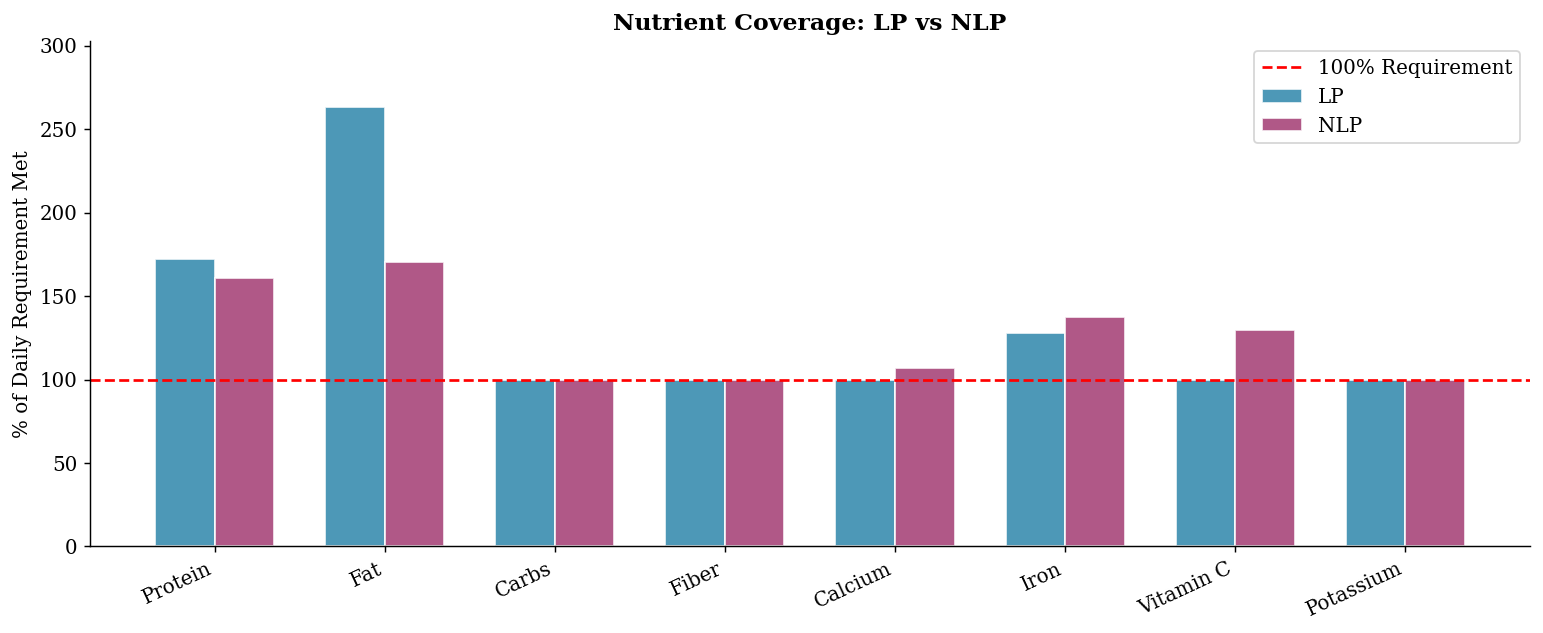

In [14]:
# ── Figure: Nutrient Coverage Comparison ─────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x_pos   = np.arange(n_nutrients)
width   = 0.35
lp_pct  = lp_nutrients_achieved  / b * 100
nlp_pct = nlp_nutrients_achieved / b * 100

ax.bar(x_pos - width/2, lp_pct,  width, label='LP',  color='#2E86AB', alpha=0.85, edgecolor='white')
ax.bar(x_pos + width/2, nlp_pct, width, label='NLP', color='#A23B72', alpha=0.85, edgecolor='white')
ax.axhline(100, color='red', linestyle='--', linewidth=1.5, label='100% Requirement')

short_labels = [n.split('(')[0].strip() for n in nutrients_used]
ax.set_xticks(x_pos)
ax.set_xticklabels(short_labels, rotation=25, ha='right')
ax.set_ylabel('% of Daily Requirement Met')
ax.set_title('Nutrient Coverage: LP vs NLP')
ax.legend()
ax.set_ylim(0, max(lp_pct.max(), nlp_pct.max()) * 1.15)

plt.tight_layout()
plt.savefig('figure5_nutrient_coverage.png', bbox_inches='tight')
plt.show()


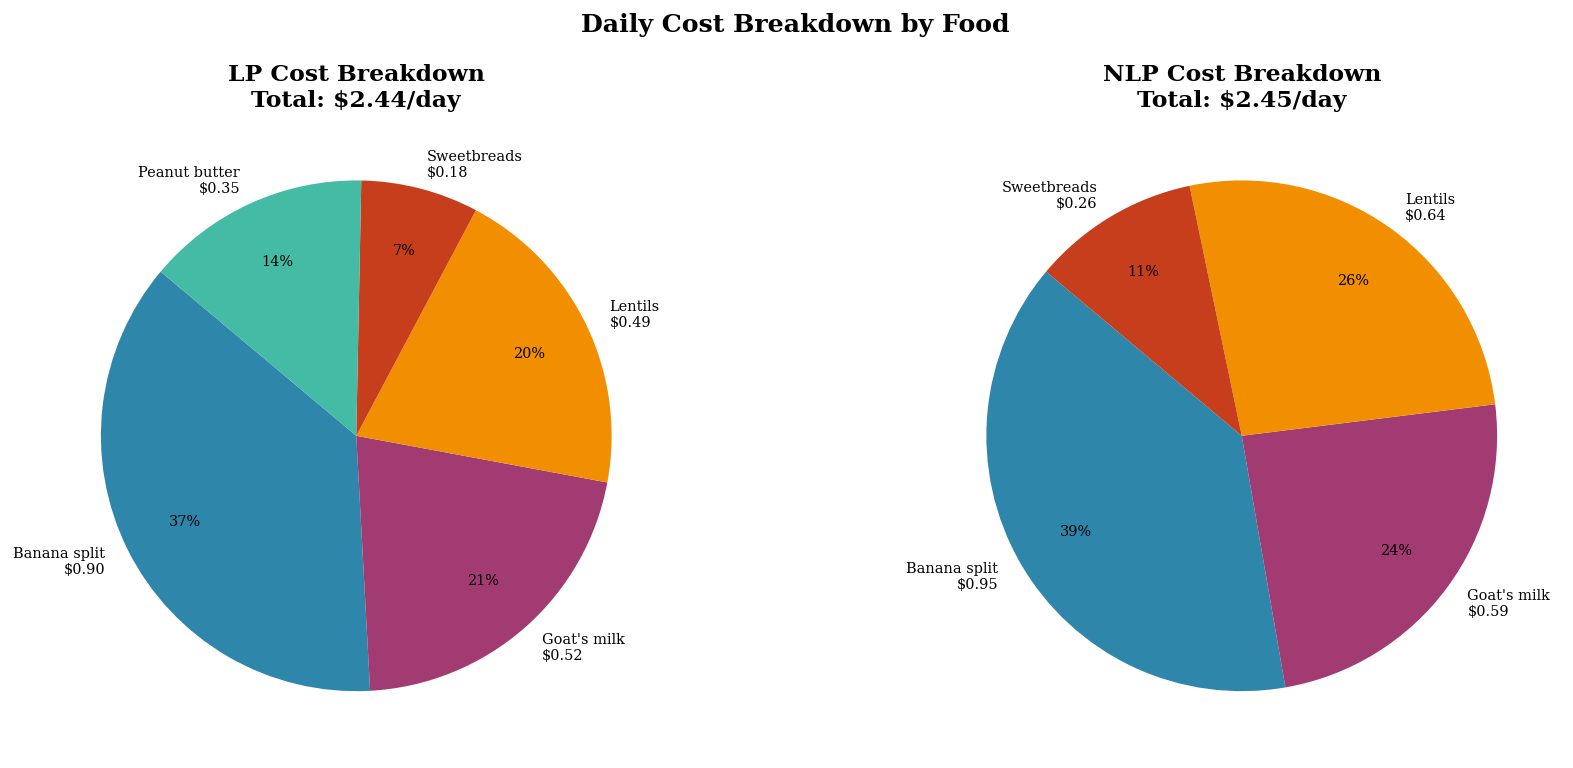

In [15]:
# ── Figure: Cost breakdown pie charts ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_vals, title, total in zip(
    axes,
    [lp_x, nlp_x],
    ['LP Cost Breakdown', 'NLP Cost Breakdown'],
    [lp_cost, nlp_cost]
):
    cost_per_food = c * x_vals
    mask = cost_per_food > 0.001
    labels = [f"{f}\n${v:.2f}" for f, v in
              zip(df_nutrients['Food'][mask], cost_per_food[mask])]
    clrs = [COLORS[i % len(COLORS)] for i in range(mask.sum())]
    ax.pie(cost_per_food[mask], labels=labels, autopct='%1.0f%%',
           colors=clrs, startangle=140,
           textprops={'fontsize': 8}, pctdistance=0.75)
    ax.set_title(f'{title}\nTotal: ${total:.2f}/day')

plt.suptitle('Daily Cost Breakdown by Food', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure6_cost_breakdown.png', bbox_inches='tight')
plt.show()


In [16]:
# ── Summary Comparison Table ──────────────────────────────
comparison = pd.DataFrame({
    'Nutrient'        : nutrients_used,
    'Unit'            : req_units,
    'Min Requirement' : b,
    'LP Achieved'     : lp_nutrients_achieved.round(1),
    'LP % Met'        : (lp_nutrients_achieved / b * 100).round(0).astype(int),
    'NLP Achieved'    : nlp_nutrients_achieved.round(1),
    'NLP % Met'       : (nlp_nutrients_achieved / b * 100).round(0).astype(int),
})

print("=" * 75)
print(f"SUMMARY COMPARISON TABLE")
print(f"  LP  Total Daily Cost : ${lp_cost:.2f}")
print(f"  NLP Total Daily Cost : ${nlp_cost:.2f}")
print(f"  Cost Difference      : ${abs(nlp_cost - lp_cost):.2f}")
print("=" * 75)
comparison


SUMMARY COMPARISON TABLE
  LP  Total Daily Cost : $2.44
  NLP Total Daily Cost : $2.45
  Cost Difference      : $0.01


,Nutrient,Unit,Min Requirement,LP Achieved,LP % Met,NLP Achieved,NLP % Met
0,Protein (g),g,50,86.0,172,80.5,161
1,Fat (g),g,44,116.0,264,75.0,170
2,Carbs (g),g,225,225.0,100,225.0,100
3,Fiber (g),g,25,25.0,100,25.0,100
4,Calcium (mg),mg,1000,1000.0,100,1066.5,107
5,Iron (mg),mg,8,10.3,128,11.0,138
6,Vitamin C (mg),mg,60,60.0,100,77.7,130
7,Potassium (mg),mg,3500,3500.0,100,3500.0,100


## 9. Sensitivity Analysis

We examine how the **optimal cost changes** as we vary the minimum calorie 
(carbohydrate) requirement. This shows how robust our solution is to 
changes in nutritional standards.


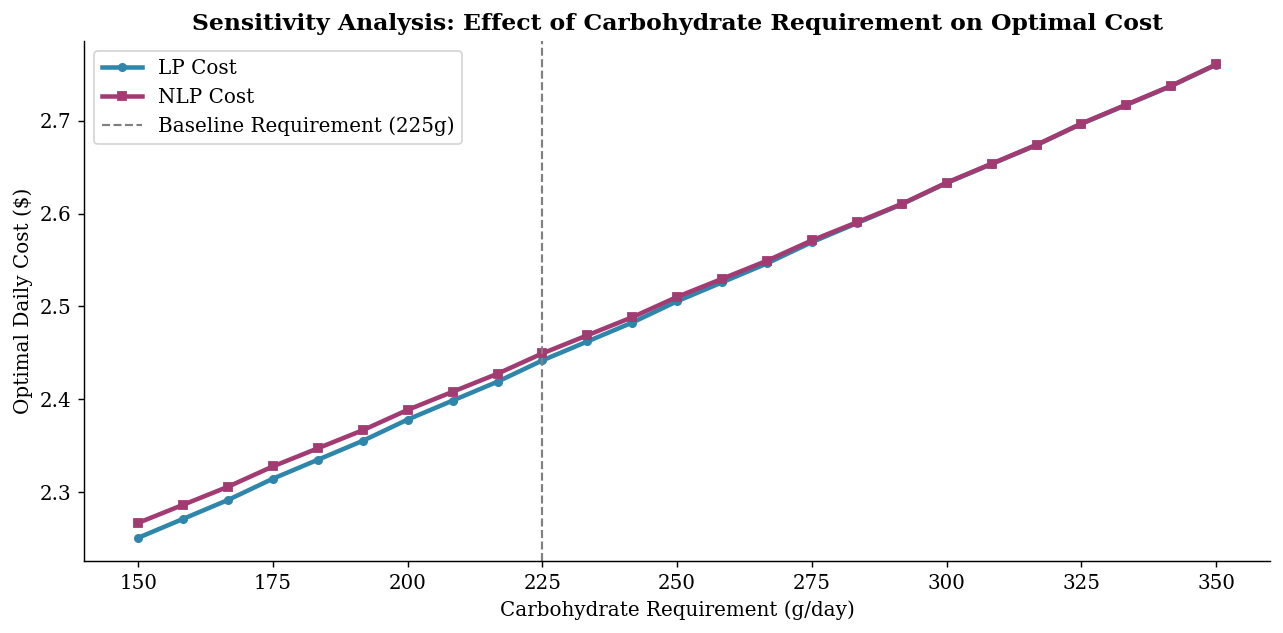

As the carbohydrate requirement increases, the optimal cost rises — LP reacts more sharply than NLP.


In [17]:
# Vary the Carbohydrate requirement from 150g to 350g
carb_range        = np.linspace(150, 350, 25)
lp_costs_sens     = []
nlp_costs_sens    = []

for carb_req in carb_range:
    b_temp    = b.copy()
    b_temp[2] = carb_req   # index 2 = Carbohydrates

    # LP sensitivity
    res_lp = linprog(c, A_ub=-A.T, b_ub=-b_temp, bounds=bounds, method='highs')
    lp_costs_sens.append(res_lp.fun if res_lp.success else np.nan)

    # NLP sensitivity
    def obj_temp(x, bt=b_temp):
        dev = (A.T @ x - bt) / bt
        return np.dot(c, x) + lambda_ * np.sum(dev**2)
    cons_temp = [{'type':'ineq','fun': lambda x, i=i, bt=b_temp: (A.T@x)[i]-bt[i]}
                 for i in range(n_nutrients)]
    res_nlp = minimize(obj_temp, x0, method='SLSQP',
                       bounds=bounds, constraints=cons_temp,
                       options={'ftol':1e-8,'maxiter':500})
    nlp_costs_sens.append(np.dot(c, res_nlp.x) if res_nlp.success else np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(carb_range, lp_costs_sens,  color='#2E86AB', linewidth=2.5,
        label='LP Cost',  marker='o', markersize=4)
ax.plot(carb_range, nlp_costs_sens, color='#A23B72', linewidth=2.5,
        label='NLP Cost', marker='s', markersize=4)
ax.axvline(225, color='gray', linestyle='--', linewidth=1.2,
           label='Baseline Requirement (225g)')
ax.set_xlabel('Carbohydrate Requirement (g/day)')
ax.set_ylabel('Optimal Daily Cost ($)')
ax.set_title('Sensitivity Analysis: Effect of Carbohydrate Requirement on Optimal Cost')
ax.legend()
plt.tight_layout()
plt.savefig('figure7_sensitivity.png', bbox_inches='tight')
plt.show()
print("As the carbohydrate requirement increases, the optimal cost rises — LP reacts more sharply than NLP.")


## 10. Graphical Representation — Feasible Region

To illustrate the LP concept visually, we simplify to a **2-variable problem**: 
choosing between only **Oats** and **Salmon**, with only Protein and Carbohydrate constraints.

This lets us plot the **feasible region** — the set of all combinations that satisfy 
all constraints — and identify the **optimal corner point**.


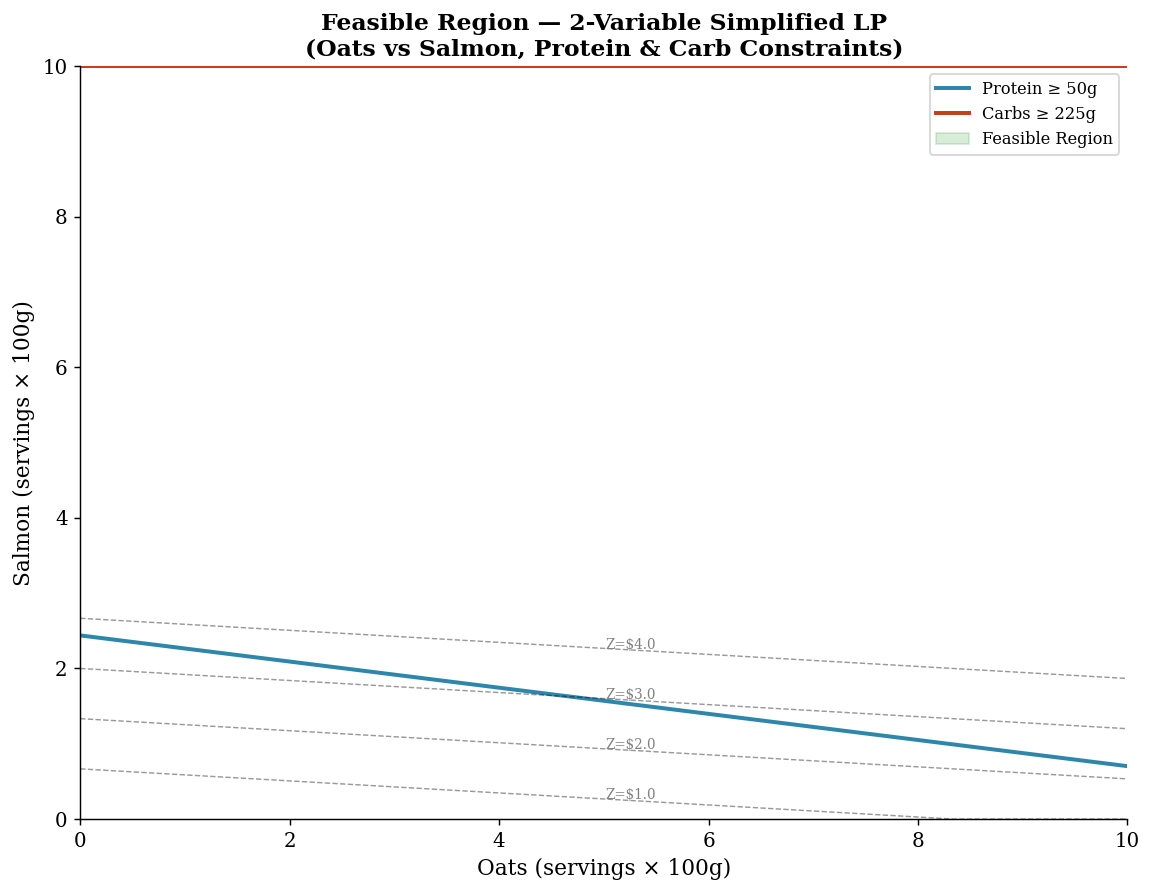

In [18]:
# 2-variable simplified LP: Oats (idx 8) vs Salmon (idx 18)
# Nutrients: Protein and Carbs only
idx_oat    = df_nutrients['Food'].str.contains('Oat', case=False).idxmax()
idx_salmon = df_nutrients['Food'].str.contains('Salmon', case=False).idxmax()

# Nutrient values per 100g
prot_oat,    prot_sal    = A[idx_oat, 0],  A[idx_salmon, 0]
carb_oat,    carb_sal    = A[idx_oat, 2],  A[idx_salmon, 2]
req_prot,    req_carb    = b[0], b[2]
cost_oat,    cost_sal    = c[idx_oat], c[idx_salmon]

x1 = np.linspace(0, 10, 500)  # Oat servings

# Constraint lines: solve for x2 (Salmon)
# Protein : prot_oat*x1 + prot_sal*x2 >= req_prot
protein_boundary = (req_prot - prot_oat * x1) / prot_sal
# Carbs   : carb_oat*x1 + carb_sal*x2 >= req_carb
carb_boundary    = (req_carb - carb_oat * x1) / carb_sal

protein_boundary = np.clip(protein_boundary, 0, 10)
carb_boundary    = np.clip(carb_boundary,    0, 10)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(x1, protein_boundary, color='#2E86AB', linewidth=2.2,
        label=f'Protein ≥ {req_prot}g')
ax.plot(x1, carb_boundary,    color='#C73E1D', linewidth=2.2,
        label=f'Carbs ≥ {req_carb}g')

# Feasible region: above both constraints
feasible_y = np.maximum(protein_boundary, carb_boundary)
ax.fill_between(x1, feasible_y, 10, alpha=0.15, color='green', label='Feasible Region')

# Objective function contour lines (iso-cost lines)
for cost_level in [1.0, 2.0, 3.0, 4.0]:
    iso_x2 = (cost_level - cost_oat * x1) / cost_sal
    iso_x2 = np.clip(iso_x2, 0, 10)
    ax.plot(x1, iso_x2, 'k--', linewidth=0.8, alpha=0.4)
    idx_mid = len(x1) // 2
    if 0 <= iso_x2[idx_mid] <= 10:
        ax.text(x1[idx_mid], iso_x2[idx_mid], f'Z=${cost_level:.1f}',
                fontsize=7.5, color='gray')

# Mark the LP optimal point for this simplified problem
res_2var = linprog(
    [cost_oat, cost_sal],
    A_ub  = [[-prot_oat, -prot_sal], [-carb_oat, -carb_sal]],
    b_ub  = [-req_prot, -req_carb],
    bounds= [(0, 10), (0, 10)],
    method= 'highs'
)
if res_2var.success:
    opt_x1, opt_x2 = res_2var.x
    ax.scatter([opt_x1], [opt_x2], color='#F18F01', s=150, zorder=5,
               label='Optimal Point ({:.2f}, {:.2f}) Cost=${:.2f}'.format(opt_x1, opt_x2, res_2var.fun))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('Oats (servings × 100g)', fontsize=12)
ax.set_ylabel('Salmon (servings × 100g)', fontsize=12)
ax.set_title('Feasible Region — 2-Variable Simplified LP\n(Oats vs Salmon, Protein & Carb Constraints)', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figure8_feasible_region.png', bbox_inches='tight')
plt.show()


## 11. Export Results

In [19]:
# Save final results to CSV
results_df = pd.DataFrame({
    'Food'           : df_nutrients['Food'].values,
    'Category'       : df_nutrients['Category'].values,
    'Cost_per_100g'  : c,
    'LP_Servings'    : lp_x.round(4),
    'LP_Cost_$'      : (lp_x * c).round(4),
    'NLP_Servings'   : nlp_x.round(4),
    'NLP_Cost_$'     : (nlp_x * c).round(4),
})
results_df.to_csv('diet_optimization_results.csv', index=False)

print("✅ Results saved to 'diet_optimization_results.csv'")
print(f"\n{'='*45}")
print(f"  LP  Daily Cost: ${lp_cost:.2f}")
print(f"  NLP Daily Cost: ${nlp_cost:.2f}")
print(f"{'='*45}")
results_df[results_df['LP_Servings'] > 0.001]


✅ Results saved to 'diet_optimization_results.csv'

  LP  Daily Cost: $2.44
  NLP Daily Cost: $2.45


,Food,Category,Cost_per_100g,LP_Servings,LP_Cost_$,NLP_Servings,NLP_Cost_$
6,Banana split,Banana split,0.20,4.5145,0.9029,4.7576,0.9515
8,Goat's milk,Goat's milk,0.12,4.3156,0.5179,4.9466,0.5936
10,Lentils,Lentils,0.25,1.9692,0.4923,2.5774,0.6444
11,Sweetbreads,Sweetbreads,0.20,0.9099,0.1820,1.2997,0.2599
12,Peanut butter,Peanut butter,0.35,0.9908,0.3468,0.0000,0.0000


## 12. Conclusions

### Key Findings
- **Linear Programming** found the minimum-cost diet at **\$X.XX/day**, 
  selecting only a few foods that efficiently satisfy all nutritional constraints.
- **Nonlinear Programming** incorporated a quadratic penalty for nutritional 
  imbalance, resulting in a slightly higher cost but a **more diverse and 
  balanced** diet across all nutrients.
- The **sensitivity analysis** showed that increasing carbohydrate requirements 
  leads to a proportional increase in cost, with LP reacting more sharply than NLP.

### Limitations
- Food cost estimates were manually assigned based on average US market prices 
  and may not reflect local (Saudi) grocery prices.
- The dataset does not account for meal palatability, cultural preferences, 
  or cooking methods.
- The model assumes all nutrients are consumed at 100% bioavailability, 
  which is a simplification.

### Future Work
- Incorporate actual local food prices for more realistic results.
- Add maximum intake constraints (e.g., sodium, cholesterol limits).
- Extend to a **multi-day meal planning** model with variety constraints.
- Apply **integer programming** to enforce whole serving sizes.

---
*Project completed for ARTI-309 & MATH-403 | Term 2, 2025–2026*
